In [109]:
using Pkg
Pkg.activate("C:/Users/av589/Desktop/Julia/ants")
using Plots
using DifferentialEquations
using LaTeXStrings
using NLsolve
using IntervalArithmetic, IntervalArithmetic.Symbols, IntervalRootFinding
using LinearAlgebra

  Activating project at `C:\Users\av589\Desktop\Julia\ants`


Using Julia's DifferentialEquations.jl package to reproduce AB's intitial trajectory for the full system.

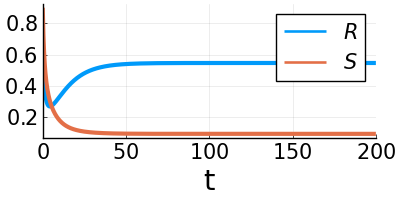

In [110]:
function AntODEs_t(x,p,t) 
    (mu,N,M,alpha,beta,nu,tau,k,p0,gamma0,n) = p
    R,S,p,gamma = x
    RS = R*S
    Rdot = alpha*(1-R) - beta * (M / N) * RS
    Sdot = gamma*(1-S) - beta * (N/M)*RS
    pdot =-mu*p + nu*(gamma*M*(1-S) + beta*N*RS)
    gammadot = tau^(-1)*(-gamma + gamma0 + k/(1 + (p0/p)^n))
    [
        Rdot
        Sdot
        pdot
        gammadot
    ]
end

function AntODEs2d(x,p,t) 
    (N,M,alpha,beta,gamma0) = p
    R,S = x
    RS = R*S
    Rdot = alpha*(1-R) - beta * (M / N) * RS
    Sdot = gamma0*(1-S) - beta * (N/M)*RS
    [
        Rdot
        Sdot
    ]
end

function hill(p,k,p0,n)
    return k/(1 + (p0/p)^n)
end

par = (mu=0.6,N=1,M=1,alpha=0.10,beta=0.9,nu=0.45,tau=1,k=1,p0=0.2,gamma0=0.05,n=4)
mu,N,M,alpha,beta,nu,tau,k,p0,gamma0,n = par
u0 = [0.7,0.9,0.5,0.1]
tspan = (0.0,200.0)
Antprob = ODEProblem(AntODEs_t,u0,tspan,par)
sol = DifferentialEquations.solve(Antprob);

par2d = (N,M,alpha,beta,gamma0)
u02d = [0.7,0.9]
Antprob2d = ODEProblem(AntODEs2d,u02d,tspan,par2d)
sol2d = DifferentialEquations.solve(Antprob2d);
plot(sol2d, idxs = (0, 1:2),label = [L"R" L"S"],linewidth = 3,size = (400,200))

In [111]:
x = range(0,1,length=1000)
y = @. hill(x,k,p0,n);

In [112]:
A = (gamma0 * M^2)/(alpha* N^2)
B = (gamma0 * M)/(beta*M)

S_star = 1/(2*A)*(A-B-1 + ((A-B-1)^2 + 4*A*B)^0.5)
R_star = B*(1-S_star)/S_star

0.5461639941580722

In [113]:
S_test = 1/(2*A) * (A-B-1 + ((B+1-A)^2 + 4*A*B)^0.5)

0.09232798831614453

In [114]:
R = [u[1] for u in sol2d.u]
S = [u[2] for u in sol2d.u]

R[end]

0.5461640298682269

In [115]:
#Plots.scalefontsizes(1/3)

In [116]:
using Plots.PlotMeasures

In [117]:
pythonplot()

Plots.PythonPlotBackend()

In [118]:
cs =palette(:default)

In [119]:
#scalefontsizes(1/2)

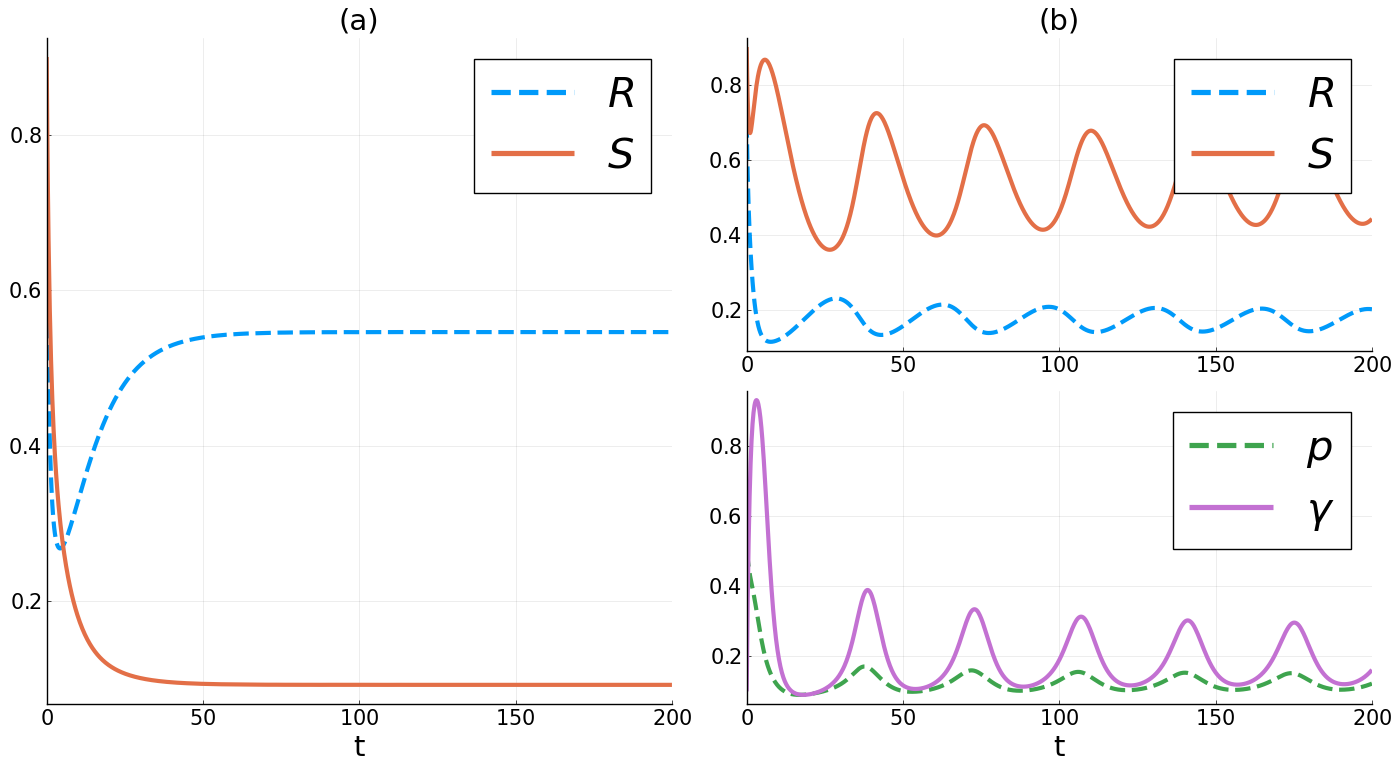

In [120]:
LFS = 30
p1 = plot(sol, idxs = (0, 1:2),label = [L"R" L"S"],linestyle=[:dash :solid],linewidth = 3,legendfontsize = LFS,title = "(b)",titlefontsize = 21,xlabel = nothing,guidefontsize = 1);
p2 = plot(sol, idxs = (0, 3:4),label = [L"p" L"\gamma"],linewidth = 3,linestyle=[:dash :solid],legendfontsize = LFS,linecolor= [cs[3] cs[4]]);
p3 = plot(sol2d, idxs = (0, 1:2),label = [L"R" L"S"],linewidth = 3,linestyle=[:dash :solid],legendfontsize = LFS,title = "(a)",titlefontsize = 21);
layout = @layout [a [b; c]]
FP = plot(p3,p1,p2,layout=layout,left_margin=2mm,size=(1400,770),bottom_margin = 2mm,right_margin= 2mm,top_margin = 2mm)
#png(FP,"trajectories")

In [121]:
2.5*1.1

2.75

In [122]:
size(sol.u)

(128,)

In [123]:
sol.t[245:end]

Float64[]

In [124]:
R = [u[1] for u in sol.u]
S = [u[2] for u in sol.u]
p = [u[3] for u in sol.u]
gamma = [u[4] for u in sol.u];

In [125]:
#println(maximum(R[245:end]))
##println(minimum(R[245:end]))
#println(maximum(S[245:end]))
#println(minimum(S[245:end]))

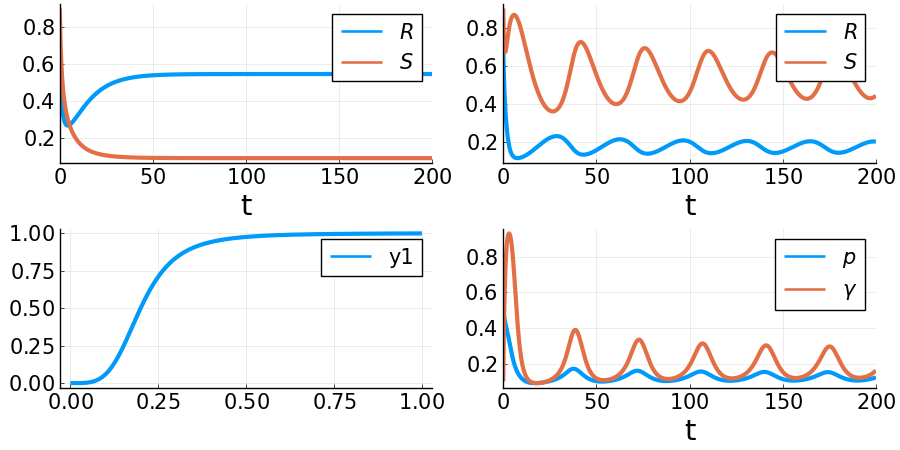

In [191]:

p1 = plot(sol, idxs = (0, 1:2),label = [L"R" L"S"],linewidth = 3);
p2 = plot(sol, idxs = (0, 3:4),label = [L"p" L"\gamma"],linewidth = 3);
p3 = plot(sol2d, idxs = (0, 1:2),label = [L"R" L"S"],linewidth = 3);
p4 = plot(x,y,linewidth = 3);
layout = @layout [a b ;c d]
plot(p3,p1,p4,p2,layout=layout,size = (900,450),left_margin=2mm)

In [20]:
Plots.scalefontsizes(1.25)

In [22]:
k,p0,n

(1, 0.2, 4)

In [23]:
x = range(0,1,length=1000)
y = @. hill(x,k,p0,n);
y2 = @. hill(x,k,p0,2);
y3 = @. hill(x,k,p0,0.5);

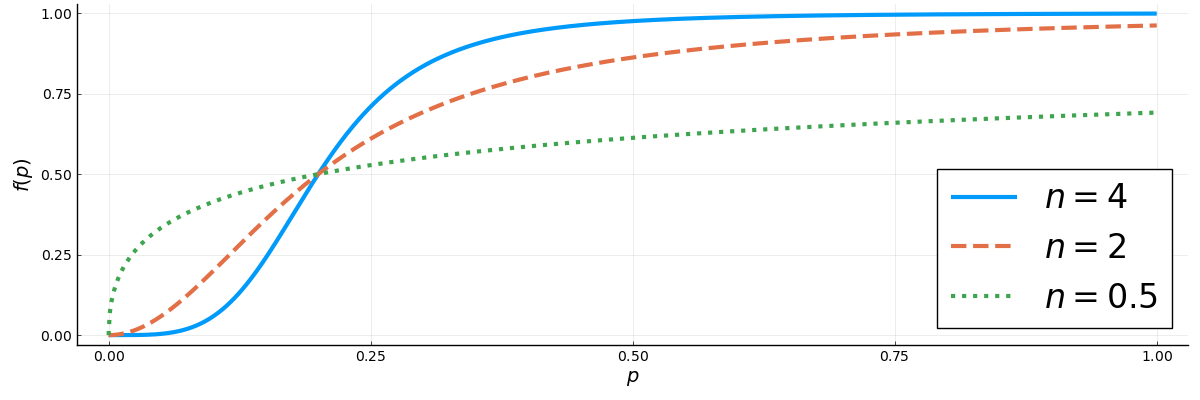

In [24]:
p4 = plot(x,[y,y2,y3],linewidth = 3,xlabel = L"$p$",ylabel = L"$f(p)$",right_margin= 3mm,left_margin= 3mm,bottom_margin=3mm,
            label = [L"$n=4$" L"$n=2$" L"n=0.5"],linestyle=[:solid :dash :dot],size = (1200,400),legend = :bottomright,legendfontsize= 24)
#savefig("hill")


In [25]:
2* 1.25

2.5

## Multi-Nest

$K \in \mathbb{N}$ nests. $3K+1$ ODEs.

$$
\begin{align}
\frac{d R_i}{dt} &= \alpha (1 - R_i) - \beta \frac{M}{N_i} R_i S_i,  \\
\frac{d S_i}{dt} &= \gamma_i \left(1 - \sum_{j=1}^K S_j\right) - \beta \frac{N_i}{M} R_i S_i,  \\
\frac{dp}{dt} &= - \mu p + \nu \sum_{i=1}^K \left( \gamma_i M \left(1 -\sum_{j = 1}^K S_j \right) + \beta N_i R_i S_i \right), \\
\tau_{\gamma} \frac{d \gamma_i}{dt} &= - \gamma_i + f(p) + \gamma_{i0}.
\end{align}
$$

In [95]:
k

1

In [222]:
function AntODEs_full(x,p,t) 
    (mu,Nlist,M,alpha,beta,nu,tau,k,p0,gamma0list,n,K) = p
    
    Rdot = zeros(K)
    Sdot = zeros(K)
    gammadot = zeros(K)
    S_total = sum(x[K+1:2*K]) # sum of S_Js
    pdot_sum = 0
    p = x[3*K + 1]
    
    #println(Nlist)
    for i in 1:K
        R = x[i]
        S = x[i + K]
        gamma = x[i + 2*K]
        
        Rdot[i] = alpha*(1-R) - beta *(M/Nlist[i])*R*S
        Sdot[i] = gamma*(1-S_total) - beta*(Nlist[i]/M)*R*S
        gammadot[i] = tau^(-1)*(-gamma + gamma0list[i] + k/(1 + (p0/p)^n))
        
        pdot_sum += gamma*M*(1-S_total) + beta*Nlist[i]*R*S
    end
   # println(S_total)
    pdot = -mu*p + nu*pdot_sum

    return vcat(Rdot,Sdot,gammadot,pdot)
end

AntODEs_full (generic function with 1 method)

In [232]:
K = 3
Nlist = [N/K for i in 1:K] # list of K N_i values
gamma0list = [gamma0 for i in 1:K] # list of K gamma0_i values

par_full = (mu=0.6,Nlist,M=1,alpha=0.10,beta=0.9,nu=0.45,tau=1,k=1,p0=0.2,gamma0list,n=4,K)
#mu,N,M,alpha,beta,nu,tau,k,p0,gamma0,n = par
u0 = [0.7,0.9,0.5,0.1] # R,S,p,gamma
R_IC = [u0[1] for i in 1:K]
S_IC = [u0[2]/K for i in 1:K]
println(sum(S_IC), " must be less than one")
gamma_IC = [u0[4] for i in 1:K]
p_IC = u0[3]
u0_full = vcat(R_IC,S_IC,gamma_IC,p_IC)


tspan = (0.0,100.0)
Antprob_full = ODEProblem(AntODEs_full,u0_full,tspan,par_full)
sol_full = DifferentialEquations.solve(Antprob_full);

0.8999999999999999 must be less than one


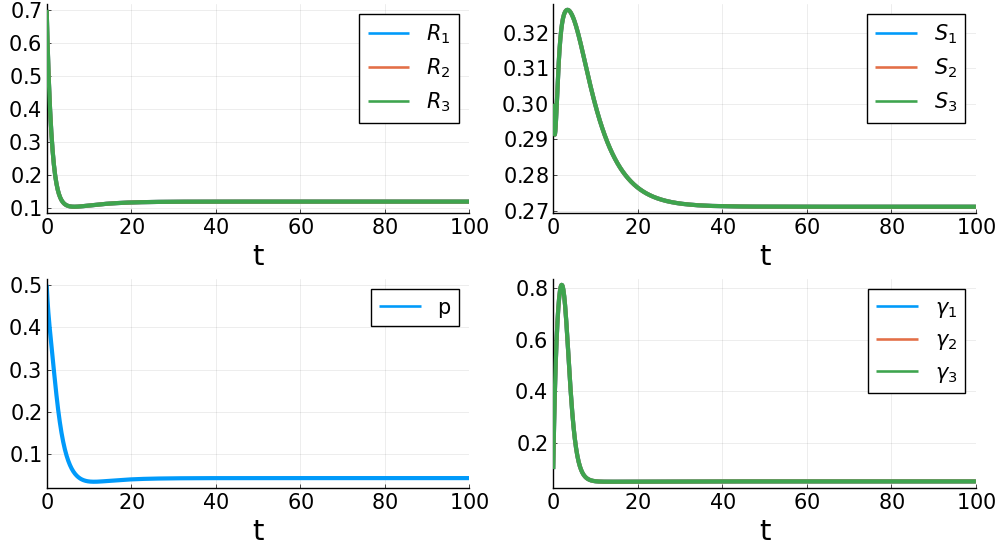

In [ ]:
R_labels = reshape([latexstring("R_" * string(i)) for i in 1:K],1,:)
S_labels = reshape([latexstring("S_" * string(i)) for i in 1:K],1,:)
gamma_labels = reshape([latexstring("\$\\gamma_" * string(i)*"\$") for i in 1:K],1,:)

p1 = plot(sol_full, idxs = (0, 1:K),linewidth = 3, label = R_labels);
p2 = plot(sol_full, idxs = (0, K+1:2*K),linewidth = 3,label = S_labels);
p3 = plot(sol_full, idxs = (0, 2*K+1:3*K),linewidth = 3,label = gamma_labels);
p4 = plot(sol_full, idxs = (0,3*K + 1),linewidth = 3, label = "p");
layout = @layout [a b ;c d]
plot(p1,p2,p4,p3,layout=layout,size = (1000,550),left_margin=2mm)

0.8999999999999999 must be less than one


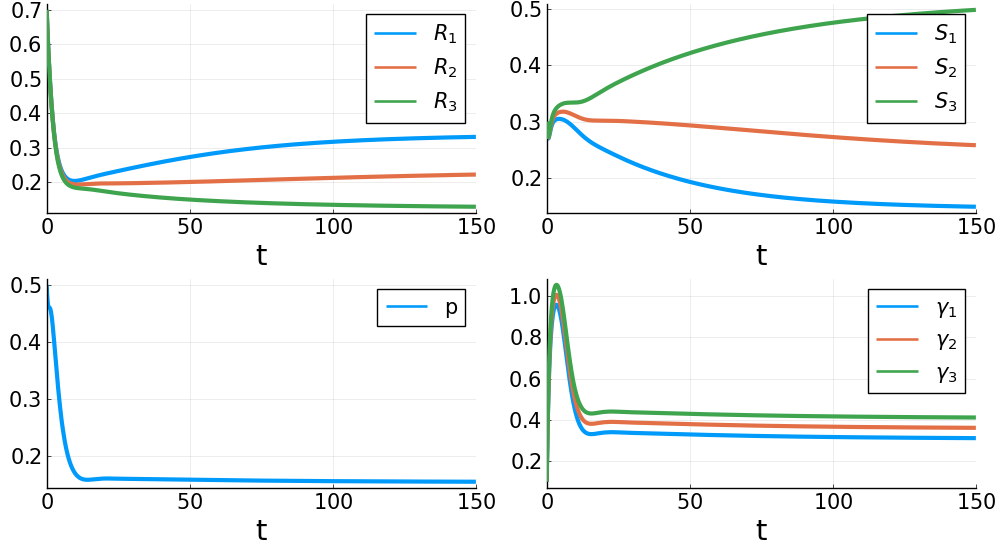

In [245]:
K = 3
Nlist = 2 .* [N/K for i in 1:K] # list of K N_i values # MULTIPLIED BY 2
gamma0list = [gamma0 for i in 1:K] # list of K gamma0_i values
gamma0list = [0.05,0.1,0.15] # THIS IS WHAT IS DIFFERENT

par_full = (mu=0.6,Nlist,M=1,alpha=0.10,beta=0.9,nu=0.45,tau=1,k=1,p0=0.2,gamma0list,n=4,K)
#mu,N,M,alpha,beta,nu,tau,k,p0,gamma0,n = par
u0 = [0.7,0.9,0.5,0.1] # R,S,p,gamma
R_IC = [u0[1] for i in 1:K]
S_IC = [u0[2]/K for i in 1:K]
println(sum(S_IC), " must be less than one")
gamma_IC = [u0[4] for i in 1:K]
p_IC = u0[3]
u0_full = vcat(R_IC,S_IC,gamma_IC,p_IC)


tspan = (0.0,150.0)
Antprob_full = ODEProblem(AntODEs_full,u0_full,tspan,par_full)
sol_full = DifferentialEquations.solve(Antprob_full);


R_labels = reshape([latexstring("R_" * string(i)) for i in 1:K],1,:)
S_labels = reshape([latexstring("S_" * string(i)) for i in 1:K],1,:)
gamma_labels = reshape([latexstring("\$\\gamma_" * string(i)*"\$") for i in 1:K],1,:)


p1 = plot(sol_full, idxs = (0, 1:K),linewidth = 3, label = R_labels);
p2 = plot(sol_full, idxs = (0, K+1:2*K),linewidth = 3,label = S_labels);
p3 = plot(sol_full, idxs = (0, 2*K+1:3*K),linewidth = 3,label = gamma_labels);
p4 = plot(sol_full, idxs = (0,3*K + 1),linewidth = 3, label = "p");
layout = @layout [a b ;c d]
plot(p1,p2,p4,p3,layout=layout,size = (1000,550),left_margin=2mm)

In [247]:
p = [u[3*K+1] for u in sol_full.u]

39-element Vector{Float64}:
 0.5
 0.4920570040060134
 0.47572274480347676
 0.4645610197915153
 0.46090147737327886
 0.45975910523571756
 0.4547975969898299
 0.4401410500613768
 0.40443072381036393
 0.3727355902363835
 ⋮
 0.1579083256233282
 0.15738393988302699
 0.1568544845764169
 0.15631144301456862
 0.15578767853596812
 0.15528436046725794
 0.15483012622243342
 0.1544242152439457
 0.15425363609776155

In [254]:
abs(p[end] - p[end-5])

0.00205780691680707

In [265]:
rand(5)

5-element Vector{Float64}:
 0.7644242610688687
 0.061216032353200056
 0.5260555079809356
 0.38528850254558134
 0.6069615642720261

In [ ]:
threshold = 0.05
while heuristic < threshold
    
end